# 📘Домашнє завдання №10 Лінійна регресія

Виконав: **Bohdan Pinchuk**

Link: https://github.com/BogdanPinchuk/DataScience-PBY_HW10

Основні метрики
* MAE - mean absolute error (середня абсолютна похибка)
$$ MAE = \frac{1}{N} \sum_{i=1}^{N} |y_i - \hat{y}_i| $$
* MSE - mean squared error (середньоквадратичне відхилення)
$$ MSE = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2 $$
* RMSE - root mean squared error (корінь середньоквадратичного відхилення)
$$ RMSE = \sqrt{MSE} $$
* R² - coefficient of determination (коефіцієнт детермінації)
$$ R^2 = 1 - \frac{MSE}{\sum_{i=1}^{N} (y_i - \bar{y})^2} $$

Дано датасет:
| Площа (м²) | Кількість кімнат | Ціна ($ тис.) |
|----------|-------|----------------|
| 40       | 1     | 120            |
| 45       | 2     | 135            |
| 50       | 2     | 150            |
| 55       | 2     | 165            |
| 60       | 3     | 180            |
| 65       | 3     | 195            |
| 70       | 3     | 205            |
| 75       | 3     | 215            |
| 80       | 3     | 225            |
| 85       | 4     | 240            |
| 90       | 4     | 255            |
| 95       | 4     | 270            |
| 100      | 4     | 285            |
| 105      | 4     | 300            |
| 110      | 5     | 315            |
| 115      | 5     | 330            |
| 120      | 5     | 345            |
| 125      | 5     | 360            |
| 130      | 6     | 380            |
| 140      | 6     | 410            |

**Завдання**:
1. Побудуйте просту лінійну регресію — використайте тільки площу (м²) для передбачення ціни, обчисліть MSE.
2. Якою буде ціна для квартири 90 м²?
3. Використайте площу та кількість кімнат. Як зміниться MSE?
4. Побудуйте графік і проведіть лінію регресії:
   - X: площа
   - Y: ціна
5. Побудуйте Ridge та Lasso Regression, порівняйте з моделлю, отриманою в п.3.
  


In [1]:
import numpy as np
import pandas as pd
import jinja2
from pandas.io.formats.style import Styler

class Reporter:
    """
    Class for collecting and printing data in tabular form
    """

    def __init__(self, attribute_col: str = "Attribute", result_col: str = "Result"):
        self._border_sign = "#"
        self._hor_split_sign = "~"
        self._ver_split_sign = "|"
        self._tolerance = 4
        self._max_len_lf: int = 0
        self._max_len_rt: int = 0
        self._data_list: list[tuple[str, str]] = []
        self.attribute_col = attribute_col
        self.result_col = result_col

    @property
    def max_len_lf(self) -> int:
        """Maximum left column width (the 1st column)"""
        return self._max_len_lf

    @property
    def max_len_rt(self) -> int:
        """Maximum right column width (the 2nd column)"""
        return self._max_len_rt

    @property
    def data_list(self) -> list[tuple[str, str]]:
        """The list of data to be printed"""
        return self._data_list

    @property
    def border_sign(self) -> str:
        """Character used for the outside table border"""
        return self._border_sign

    @border_sign.setter
    def border_sign(self, value: str) -> None:
        self._border_sign = value

    @property
    def hor_split_sign(self) -> str:
        """Character used for horizontal splitter in tabular form"""
        return self._hor_split_sign

    @hor_split_sign.setter
    def hor_split_sign(self, value: str) -> None:
        self._hor_split_sign = value

    @property
    def ver_split_sign(self) -> str:
        """Character used for vertical splitter in tabular form"""
        return self._ver_split_sign

    @ver_split_sign.setter
    def ver_split_sign(self, value: str) -> None:
        self._ver_split_sign = value

    @property
    def tolerance(self) -> int:
        """Number of digits after the floating point"""
        return self._tolerance

    @tolerance.setter
    def tolerance(self, value: int) -> None:
        self._tolerance = value

    @property
    def attribute_col(self) -> str:
        """Name of the attribute (the 1st column)"""
        return self._attribute_col

    @attribute_col.setter
    def attribute_col(self, value: str) -> None:
        array_str_key = value.splitlines()
        for str_key in array_str_key:
            self._max_len_lf = max(self.max_len_lf, len(str_key))
        self._attribute_col = value

    @property
    def result_col(self) -> str:
        """Name of the result (the 2nd column)"""
        return self._result_col

    @result_col.setter
    def result_col(self, value: str) -> None:
        array_str_value = value.splitlines()
        for str_value in array_str_value:
            self._max_len_rt = max(self.max_len_rt, len(str_value))
        self._result_col = value

    def format_value(self, value: float) -> str:
        """
        Format value to string
        :param value: input value
        :return: string of the value
        """
        return f"{value:.{self.tolerance}f}"

    def format_matrix(self, matrix: np.ndarray) -> str:
        """
        Formatting matrix into string
        :param matrix: input matrix
        :return: string of the matrix
        """
        return np.array2string(matrix, precision=self.tolerance)

    def add_item(self, key: str, value: str) -> None:
        """
        Form the report data that consist multi strings
        :param key: attribute
        :param value: result
        """
        array_str_key = key.splitlines()
        array_str_value = value.splitlines()

        for str_key in array_str_key:
            self._max_len_lf = max(self.max_len_lf, len(str_key))

        for str_value in array_str_value:
            self._max_len_rt = max(self.max_len_rt, len(str_value))

        self._data_list.append((key, value))

    def _print_line_splitter(self, sign: str = "-") -> None:
        """
        Print line splitter
        """
        print(sign * (self.max_len_lf + self.max_len_rt + 5))

    def _print_multi_string(self, row: tuple[str, str]) -> None:
        """
        Print the multi-string
        :param row: tuple of data
        """
        array_str_key = row[0].splitlines()
        array_str_value = row[1].splitlines()
        num_str = max(len(array_str_key), len(array_str_value))

        for index in range(num_str):
            if index < len(array_str_key):
                left_str = f"{f"{array_str_key[index]}":<{self.max_len_lf}}"
            else:
                left_str = f"{f" ":<{self.max_len_lf}}"

            if index < len(array_str_value):
                right_str = f"{f"{array_str_value[index]:<{self.max_len_rt}}"}"
            else:
                right_str = f"{f" ":<{self.max_len_rt}}"

            print(f" {left_str} {self.ver_split_sign} {right_str}")

    def refresh_table_config(self) -> None:
        """
        Refresh table configuration, like line lengths
        :return:
        """
        self._max_len_lf = 0
        self._max_len_rt = 0

        self.attribute_col = self.attribute_col
        self.result_col = self.result_col

        temp_data_list = self.data_list
        self._data_list = []
        for temp_data in temp_data_list:
            self.add_item(temp_data[0], temp_data[1])

    def print_report(self) -> None:
        """
        Print report data
        """
        self._print_line_splitter(self.border_sign)
        self._print_multi_string((self.attribute_col, self.result_col))
        self._print_line_splitter(self.border_sign)
        for item_data in self.data_list[0:-1]:
            self._print_multi_string(item_data)
            self._print_line_splitter("~")
        self._print_multi_string(self.data_list[-1])
        self._print_line_splitter(self.border_sign)

    def print_refreshed_report(self) -> None:
        """
        Print report data with a refreshing table
        """
        self.refresh_table_config()
        self.print_report()

    def get_pd_report(self) -> Styler:
        """
        Generate report data using pandas dataframe
        """
        df_data_list = pd.DataFrame(self.data_list, columns=[self.attribute_col, self.result_col])
        pd.set_option('display.max_colwidth', None)
        df_data_list = (df_data_list.style.hide(axis='index')
        .set_properties(**{
            'text-align': 'left',
            'white-space': 'pre-wrap',
            'border': '1px solid lightgrey'
        }).set_table_styles([  # type: ignore
            {"selector": "th", "props": [("text-align", "left")]}
        ]))
        return df_data_list

    def print_pd_report(self) -> None:
        """
        Print report data using pandas dataframe
        """
        df_data_list = self.get_pd_report()
        display(df_data_list)


In [2]:
import pandas as pd

# Input data
tolerance = 3
area_col_name = "area"
rooms_col_name = "rooms"
price_col_name = "price"
apr_col_name = "area_per_room"
mae_name = "neg_mean_absolute_error"
mse_name = "neg_mean_squared_error"
rmse_name = "neg_root_mean_squared_error"
r2_name = "r2"
scorings = {
    'mae': mae_name,
    'mse': mse_name,
    'rmse': rmse_name,
    'r2': r2_name,
}

data = {
    area_col_name: [40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 105, 110, 115, 120, 125, 130, 140],
    rooms_col_name: [1, 2, 2, 2, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 5, 5, 5, 5, 6, 6],
    price_col_name: [120, 135, 150, 165, 180, 195, 205, 215, 225, 240, 255, 270, 285, 300, 315, 330, 345, 360, 380,
                     410],
}

# Solution
df = pd.DataFrame(data)
df[apr_col_name] = df.apply(lambda df_row: df_row[area_col_name] / df_row[rooms_col_name], axis=1)

grouped_by_room_df = df.groupby(rooms_col_name).agg(["count", "min", "mean", "max"])

# Pearson
pearson_matrix = df.drop(columns=apr_col_name).corr(method='pearson').round(tolerance)
# Spearman
spearman_matrix = df.drop(columns=apr_col_name).corr(method='spearman').round(tolerance)

# Print results
display(grouped_by_room_df.style.set_caption("Grouped by rooms").format(precision=tolerance))
display(df.style.set_caption("Dataset"))
display(pearson_matrix.style.set_caption("Pearson's correlation").format(precision=tolerance))
display(spearman_matrix.style.set_caption("Spearman's correlation").format(precision=tolerance))

,area,rooms,price,area_per_room
0,40,1,120,40.000000
1,45,2,135,22.500000
2,50,2,150,25.000000
3,55,2,165,27.500000
4,60,3,180,20.000000
5,65,3,195,21.666667
6,70,3,205,23.333333
7,75,3,215,25.000000
8,80,3,225,26.666667
9,85,4,240,21.250000


,area,rooms,price
area,1.000,0.974,0.999
rooms,0.974,1.000,0.975
price,0.999,0.975,1.000


,area,rooms,price
area,1.000,0.979,1.000
rooms,0.979,1.000,0.979
price,1.000,0.979,1.000


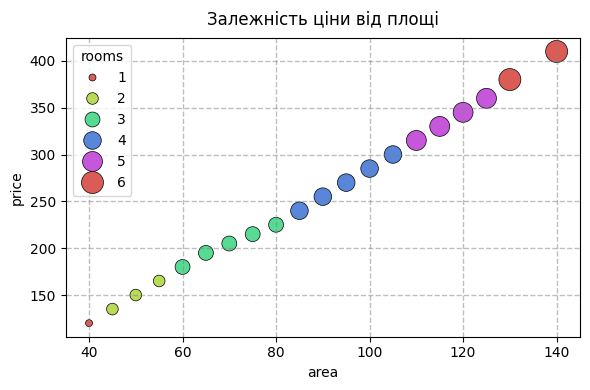

In [3]:
# Graphic results

import seaborn as sns
import matplotlib.pyplot as plt

# Input data

# Solution
_, ax = plt.subplots(figsize=(6, 4))

sns.scatterplot(data=df, ax=ax, x=area_col_name, y=price_col_name, hue=rooms_col_name, palette="hls",
                size=rooms_col_name, sizes=(25, 250), linewidth=0.5, edgecolor="black")

ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
ax.set_title("Залежність ціни від площі", pad=10, loc='center', color='black')

plt.tight_layout()
plt.show()

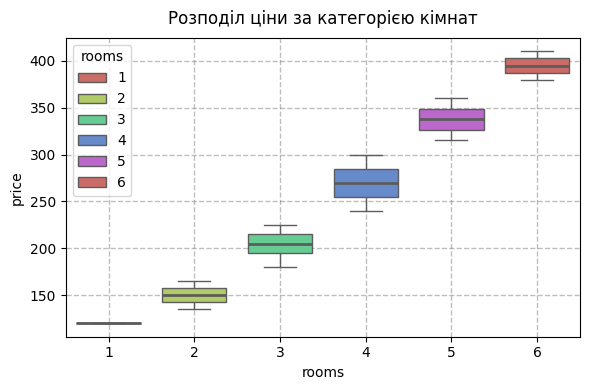

In [4]:
# Graphic results

import seaborn as sns
import matplotlib.pyplot as plt

# Input data

# Solution
_, ax = plt.subplots(figsize=(6, 4))

sns.boxplot(df, ax=ax, x=rooms_col_name, y=price_col_name, hue=rooms_col_name, palette="hls",
            width=0.75, medianprops={'linewidth': 2.0})

ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
ax.set_title("Розподіл ціни за категорією кімнат", pad=10, loc='center', color='black')

plt.tight_layout()
plt.show()

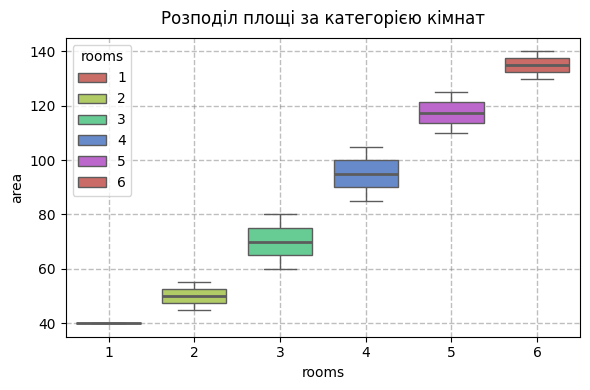

In [5]:
# Graphic results

import seaborn as sns
import matplotlib.pyplot as plt

# Input data

# Solution
_, ax = plt.subplots(figsize=(6, 4))

sns.boxplot(df, ax=ax, x=rooms_col_name, y=area_col_name, hue=rooms_col_name, palette="hls",
            width=0.75, medianprops={'linewidth': 2.0})

ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
ax.set_title("Розподіл площі за категорією кімнат", pad=10, loc='center', color='black')

plt.tight_layout()
plt.show()

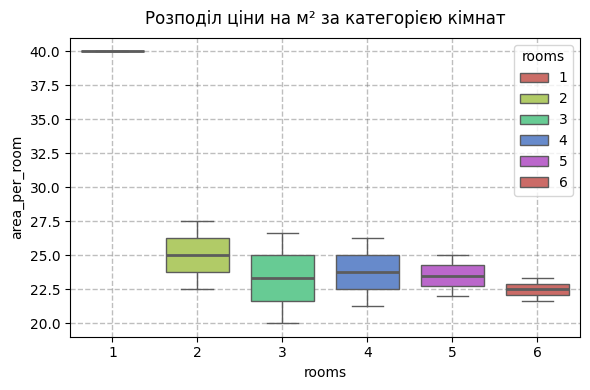

In [6]:
# Graphic results

import seaborn as sns
import matplotlib.pyplot as plt

# Input data

# Solution
_, ax = plt.subplots(figsize=(6, 4))

sns.boxplot(df, ax=ax, x=rooms_col_name, y=apr_col_name, hue=rooms_col_name, palette="hls",
            width=0.75, medianprops={'linewidth': 2.0})

ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
ax.set_title("Розподіл ціни на м² за категорією кімнат", pad=10, loc='center', color='black')

plt.tight_layout()
plt.show()

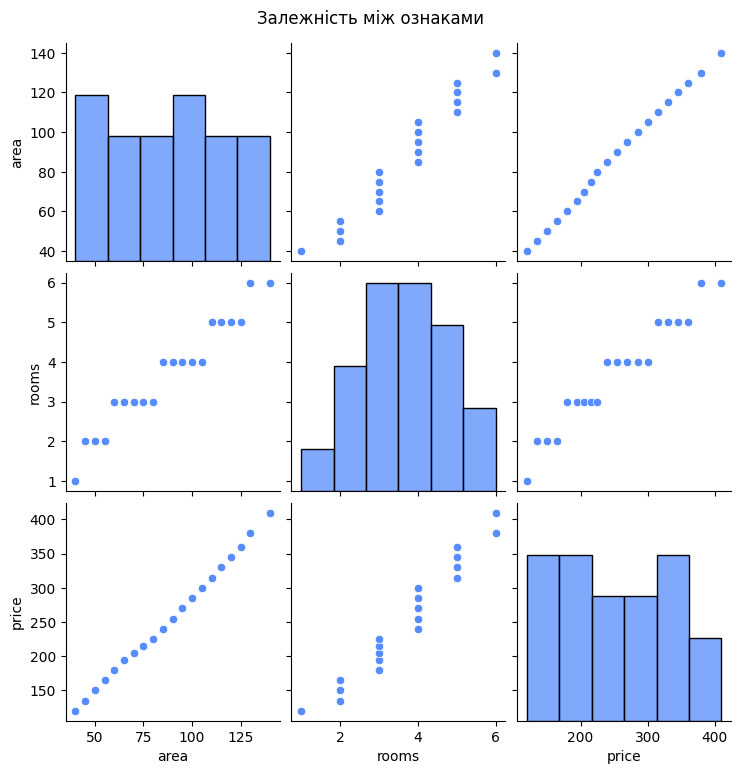

In [7]:
# Graphic results

import seaborn as sns
import matplotlib.pyplot as plt

# Input data
area_col_name = "area"
rooms_col_name = "rooms"
price_col_name = "price"

# Solution
sns.pairplot(data=df.drop(columns=apr_col_name))

plt.suptitle("Залежність між ознаками", y=1.025)

plt.show()

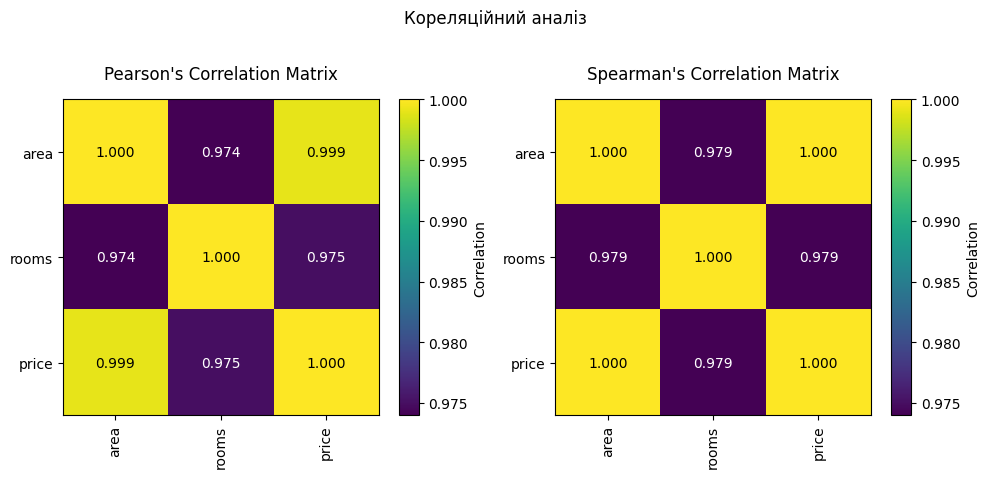

In [8]:
# Graphic results

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Input data
tolerance = 3
color_spliter = 0.99

# Solution
_, axes = plt.subplots(1, 2, figsize=(10, 5))

ax = axes[0]
data_matrix = pearson_matrix
ax.imshow(data_matrix)
ax.set_yticks(range(len(data_matrix)), labels=data_matrix.index)
ax.set_xticks(range(len(data_matrix)), labels=data_matrix.columns)
plt.setp(ax.get_xticklabels(), rotation=90)

for i in range(len(data_matrix.index)):
    for j in range(len(data_matrix.columns)):
        corr_val = data_matrix.iloc[i, j]
        ax.text(j, i, f"{corr_val:.{tolerance}f}",
                ha="center", va="center",
                color="white" if corr_val <= color_spliter else "black")

divider = make_axes_locatable(ax)
cb_ax = divider.append_axes("right", size=0.2, pad=0.2)

norm = plt.Normalize(pearson_matrix.min().min(), pearson_matrix.max().max())
sm = plt.cm.ScalarMappable(norm=norm)
sm.set_array([])
ax.figure.colorbar(sm, cax=cb_ax, label='Correlation')

ax.set_title("Pearson's Correlation Matrix", pad=15, loc='center', color='black')

ax = axes[1]
data_matrix = spearman_matrix
ax.imshow(data_matrix)
ax.set_yticks(range(len(data_matrix)), labels=data_matrix.index)
ax.set_xticks(range(len(data_matrix)), labels=data_matrix.columns)
plt.setp(ax.get_xticklabels(), rotation=90)

for i in range(len(data_matrix.index)):
    for j in range(len(data_matrix.columns)):
        corr_val = data_matrix.iloc[i, j]
        ax.text(j, i, f"{corr_val:.{tolerance}f}",
                ha="center", va="center",
                color="white" if corr_val <= color_spliter else "black")

divider = make_axes_locatable(ax)
cb_ax = divider.append_axes("right", size=0.2, pad=0.2)

norm = plt.Normalize(pearson_matrix.min().min(), pearson_matrix.max().max())
sm = plt.cm.ScalarMappable(norm=norm)
sm.set_array([])
ax.figure.colorbar(sm, cax=cb_ax, label='Correlation')

ax.set_title("Spearman's Correlation Matrix", pad=15, loc='center', color='black')

plt.suptitle(f"Кореляційний аналіз")

plt.tight_layout()
plt.show()

Висновок. Ознаки площі та ціни мають практично лінійну залежність, що підтверджується також кореляцією. При збільшенні площі квартири збільшується і ціна, тобто можна спрогнозувати, що це дані з первинного ринку, де немає цінового впливу від ремонту. Також помітна тенденція зменшення ціни за м² при збільшенні кількості кімнат у квартирі, але все ж обмежується мінімально комфортною площею для перебування в одній кімнаті, що на графіках проявляється в перетині значень площ на кімнату для різних квартир залежно від кількості кімнат у квартирі.

## Завдання 1.

Побудуйте просту лінійну регресію — використайте тільки площу (м²) для передбачення ціни, обчисліть MSE.

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_validate

# Input data
seed = 42
n_splits = 5
X_area = df[area_col_name].values.reshape(-1, 1)
Y_price = df[price_col_name].values.reshape(-1, 1)

# Solution
model_simple = LinearRegression()
kf_simple = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
scores_simple = cross_validate(model_simple, X_area, Y_price, cv=kf_simple, scoring=scorings)

rp = Reporter()
rp.tolerance = 4
rp.add_item("Кількість розбиттів датасету", str(n_splits))
rp.add_item("Кількість обʼєктів у датасеті", str(df.index.size))
rp.add_item("MSE scores", rp.format_matrix(-scores_simple["test_mse"]))
rp.add_item("Mean MSE", rp.format_value(-scores_simple["test_mse"].mean()))
rp.add_item("RMSE scores", rp.format_matrix(-scores_simple["test_rmse"]))
rp.add_item("Mean RMSE", rp.format_value(-scores_simple["test_rmse"].mean()))
rp.add_item("MAE scores", rp.format_matrix(-scores_simple["test_mae"]))
rp.add_item("Mean MAE", rp.format_value(-scores_simple["test_mae"].mean()))
rp.add_item("R² scores", rp.format_matrix(scores_simple["test_r2"]))
rp.add_item("Mean R²", rp.format_value(scores_simple["test_r2"].mean()))

score_simple_1_r2 = scores_simple["test_r2"].mean()
score_simple_1_mse = -scores_simple["test_mse"].mean()

# Print results
rp.print_pd_report()

Attribute,Result
Кількість розбиттів датасету,5
Кількість обʼєктів у датасеті,20
MSE scores,[ 3.0133 29.7247 16.8878 38.7386 13.5454]
Mean MSE,20.3820
RMSE scores,[1.7359 5.452 4.1095 6.224 3.6804]
Mean RMSE,4.2404
MAE scores,[1.5191 5.3269 3.2309 5.7236 3.1562]
Mean MAE,3.7913
R² scores,[0.9997 0.9802 0.9978 0.9946 0.9928]
Mean R²,0.9930


## Завдання 2.

Якою буде ціна для квартири 90 м²?

In [10]:
# Навчання на 80% даних

from sklearn.model_selection import train_test_split

# Input data
seed = 42
check_areas = 90.0
train_set_size = 0.8
predict_area = np.array(check_areas)

# Solution
model_simple = LinearRegression()
X_area_train, X_area_test, Y_price_train, Y_price_test = train_test_split(X_area, Y_price, test_size=1 - train_set_size,
                                                                          random_state=seed, shuffle=True)
model_simple.fit(X_area_train, Y_price_train)
beta0 = model_simple.intercept_
beta1 = model_simple.coef_[0]
beta1_deg = np.rad2deg(np.arctan(beta1))

predicted_price = model_simple.predict(predict_area.reshape(-1, 1))

real_price = df[df[area_col_name] == predict_area][price_col_name].values
diff_price = abs(real_price - predicted_price)

rp = Reporter()
rp.tolerance = 2
rp.add_item("Розмір вибірки для навчання", f"{train_set_size:.2%}")
rp.add_item("Площа для передбачення", f"{rp.format_value(predict_area.item(0))} м²")
rp.add_item("Прогнозована ціна", f"${rp.format_value(predicted_price.item(0))}k")
if real_price.size > 0:
    rp.add_item("Реальна ціна", f"${rp.format_value(real_price.item(0))}k")
    rp.add_item("Різниця між прогнозованою і реальною ціною", f"${rp.format_value(diff_price.item(0))}k")
rp.add_item("Коефіцієнт β₀", f"{beta0.item(0):.6f}")
rp.add_item("Коефіцієнт β₁", f"{beta1.item(0):.6f}")
rp.add_item("Кут нахилу β₁", f"{beta1_deg.item(0):.2f}°")

# Print results
rp.print_pd_report()

Attribute,Result
Розмір вибірки для навчання,80.00%
Площа для передбачення,90.00 м²
Прогнозована ціна,$260.21k
Реальна ціна,$255.00k
Різниця між прогнозованою і реальною ціною,$5.21k
Коефіцієнт β₀,4.504323
Коефіцієнт β₁,2.841210
Кут нахилу β₁,70.61°


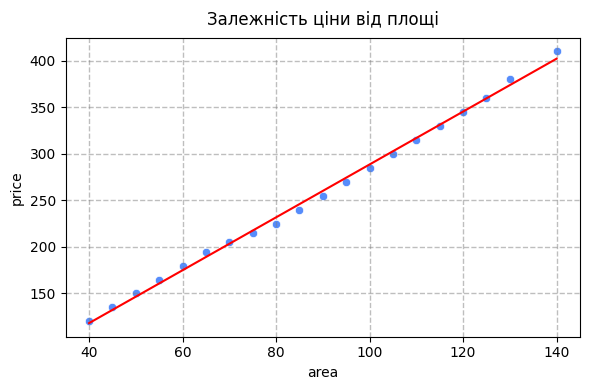

In [11]:
# Graphic results

import seaborn as sns
import matplotlib.pyplot as plt

# Input data
n_points = df.index.size

# Solution
x_data = np.linspace(df[area_col_name].min(), df[area_col_name].max(), n_points)
y_data = x_data * beta1 + beta0

_, ax = plt.subplots(figsize=(6, 4))

sns.scatterplot(data=df, ax=ax, x=area_col_name, y=price_col_name)
sns.lineplot(x=x_data, y=y_data, ax=ax, color='red')

ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
ax.set_title("Залежність ціни від площі", pad=10, loc='center', color='black')

plt.tight_layout()
plt.show()

In [12]:
# Навчання на 100% даних

# Input data
seed = 42
check_areas = 90.0
train_set_size = 1.0
predict_area = np.array(check_areas)

# Solution
model_simple = LinearRegression()
model_simple.fit(X_area, Y_price)
beta0 = model_simple.intercept_
beta1 = model_simple.coef_[0]
beta1_deg = np.rad2deg(np.arctan(beta1))

predicted_price = model_simple.predict(predict_area.reshape(-1, 1))

real_price = df[df[area_col_name] == predict_area][price_col_name].values
diff_price = abs(real_price - predicted_price)

rp = Reporter()
rp.tolerance = 2
rp.add_item("Розмір вибірки для навчання", f"{train_set_size:.2%}")
rp.add_item("Площа для передбачення", f"{rp.format_value(predict_area.item(0))} м²")
rp.add_item("Прогнозована ціна", f"${rp.format_value(predicted_price.item(0))}k")
if real_price.size > 0:
    rp.add_item("Реальна ціна", f"${rp.format_value(real_price.item(0))}k")
    rp.add_item("Різниця між прогнозованою і реальною ціною", f"${rp.format_value(diff_price.item(0))}k")
rp.add_item("Коефіцієнт β₀", f"{beta0.item(0):.6f}")
rp.add_item("Коефіцієнт β₁", f"{beta1.item(0):.6f}")
rp.add_item("Кут нахилу β₁", f"{beta1_deg.item(0):.2f}°")

# Print results
rp.print_pd_report()

Attribute,Result
Розмір вибірки для навчання,100.00%
Площа для передбачення,90.00 м²
Прогнозована ціна,$260.36k
Реальна ціна,$255.00k
Різниця між прогнозованою і реальною ціною,$5.36k
Коефіцієнт β₀,5.822323
Коефіцієнт β₁,2.828236
Кут нахилу β₁,70.53°


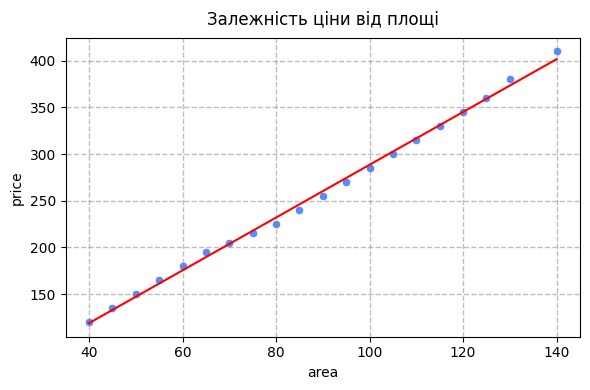

In [13]:
# Graphic results

import seaborn as sns
import matplotlib.pyplot as plt

# Input data
n_points = df.index.size

# Solution
x_data = np.linspace(df[area_col_name].min(), df[area_col_name].max(), n_points)
y_data = x_data * beta1 + beta0

_, ax = plt.subplots(figsize=(6, 4))

sns.scatterplot(data=df, ax=ax, x=area_col_name, y=price_col_name)
sns.lineplot(x=x_data, y=y_data, ax=ax, color='red')

ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
ax.set_title("Залежність ціни від площі", pad=10, loc='center', color='black')

plt.tight_layout()
plt.show()

Висновок. При навчанні моделі на всіх даних ми досягли "overfitting" перенавчання, а модель, яку навчали на 80% значень, при цьому показала кращі результати. На графіках різниця в 0.08° не помітна, а фінансово відміність між прогнозами становитиме `$`0.15k ≈ `$`150.00. Загалом же модель прогнозування дала похибку приблизно в `$`5.2k, що економічно відчутно, якщо брати іпотеку на довгий термін.

## Завдання 3.

Використайте площу та кількість кімнат. Як зміниться MSE?

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_validate

# Input data
seed = 42
n_splits = 5
X_multi = df.drop(columns=[price_col_name, apr_col_name]).values.reshape(-1, 2)
Y_price = df[price_col_name].values.reshape(-1, 1)

# Solution
model_simple = LinearRegression()
kf_simple = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
scores_simple = cross_validate(model_simple, X_multi, Y_price, cv=kf_simple, scoring=scorings)

rp = Reporter()
rp.tolerance = 4
rp.add_item("Кількість розбиттів датасету", str(n_splits))
rp.add_item("Кількість обʼєктів у датасеті", str(df.index.size))
rp.add_item("MSE scores", rp.format_matrix(-scores_simple["test_mse"]))
rp.add_item("Mean MSE", rp.format_value(-scores_simple["test_mse"].mean()))
rp.add_item("RMSE scores", rp.format_matrix(-scores_simple["test_rmse"]))
rp.add_item("Mean RMSE", rp.format_value(-scores_simple["test_rmse"].mean()))
rp.add_item("MAE scores", rp.format_matrix(-scores_simple["test_mae"]))
rp.add_item("Mean MAE", rp.format_value(-scores_simple["test_mae"].mean()))
rp.add_item("R² scores", rp.format_matrix(scores_simple["test_r2"]))
rp.add_item("Mean R²", rp.format_value(scores_simple["test_r2"].mean()))

score_simple_2_r2 = scores_simple["test_r2"].mean()
score_simple_2_mse = -scores_simple["test_mse"].mean()

# Print results
rp.print_pd_report()

Attribute,Result
Кількість розбиттів датасету,5
Кількість обʼєктів у датасеті,20
MSE scores,[ 9.2117 27.0359 14.1951 43.0331 18.4575]
Mean MSE,22.3867
RMSE scores,[3.0351 5.1996 3.7676 6.56 4.2962]
Mean RMSE,4.5717
MAE scores,[2.6981 5.1382 2.9643 5.3645 3.5445]
Mean MAE,3.9419
R² scores,[0.9992 0.982 0.9982 0.994 0.9901]
Mean R²,0.9927


Висновок. Порівнюючи за MSE, маємо зростання похибки прогнозування, де СКВ похибки зрозсло на `$`0.33k ≈ `$`331.00. Порівнюючи за середнім коефіцієнтом детермінації R², додавання додаткової ознаки "rooms" для навчання внесло погіршення в навчання і, як результат, гірша оцінка прогнозування. Перша причина — це мультиколінеарність — де площа та кількість кімнат дуже сильно корелюють між собою. Друга причина — це дискретність ознаки "rooms", що за своєю сутністю ближча до категоріального типу ознак. Третя причина — мала кількість вибірки, усього 20 обʼєктів.

## Завдання 4.

Побудуйте графік і проведіть лінію регресії:
   - X: площа
   - Y: ціна

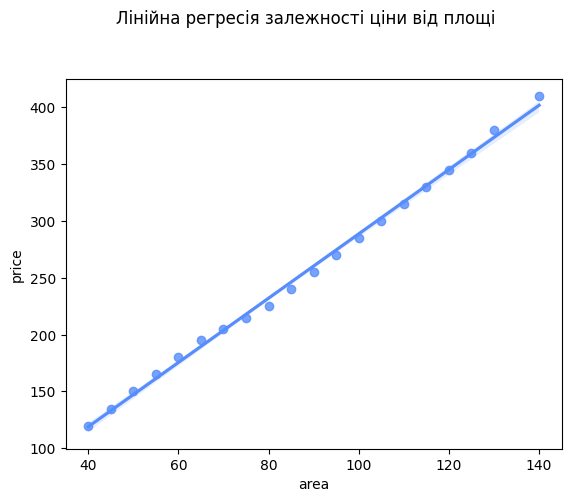

In [15]:
# Graphic results

import seaborn as sns
import matplotlib.pyplot as plt

# Input data

# Solution
sns.regplot(data=df, x=area_col_name, y=price_col_name)

plt.suptitle("Лінійна регресія залежності ціни від площі", y=1.025)

plt.show()

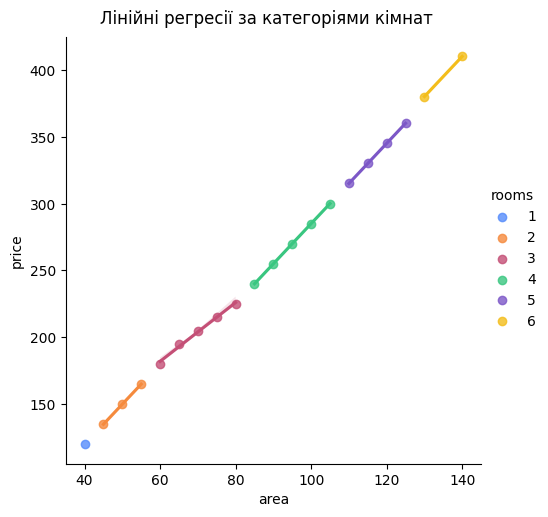

In [16]:
# Graphic results

import seaborn as sns
import matplotlib.pyplot as plt

# Input data

# Solution
sns.lmplot(data=df, x=area_col_name, y=price_col_name, hue=rooms_col_name)

plt.suptitle("Лінійні регресії за категоріями кімнат", y=1.025)

plt.show()

## Завдання 5.

Побудуйте Ridge та Lasso Regression, порівняйте з моделлю, отриманою в п.3.

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import KFold, cross_validate

# Input data
seed = 42
n_splits = 5
X_multi = df.drop(columns=[price_col_name, apr_col_name]).values.reshape(-1, 2)
Y_price = df[price_col_name].values.reshape(-1, 1)

# Solution
kf_simple = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
pipe_ls = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso())
])
scores_complex = cross_validate(pipe_ls, X_multi, Y_price, cv=kf_simple, scoring=scorings)

rp = Reporter()
rp.tolerance = 4
rp.add_item("Кількість розбиттів датасету", str(n_splits))
rp.add_item("Кількість обʼєктів у датасеті", str(df.index.size))
rp.add_item("MSE scores", rp.format_matrix(-scores_complex["test_mse"]))
rp.add_item("Mean MSE", rp.format_value(-scores_complex["test_mse"].mean()))
rp.add_item("RMSE scores", rp.format_matrix(-scores_complex["test_rmse"]))
rp.add_item("Mean RMSE", rp.format_value(-scores_complex["test_rmse"].mean()))
rp.add_item("MAE scores", rp.format_matrix(-scores_complex["test_mae"]))
rp.add_item("Mean MAE", rp.format_value(-scores_complex["test_mae"].mean()))
rp.add_item("R² scores", rp.format_matrix(scores_complex["test_r2"]))
rp.add_item("Mean R²", rp.format_value(scores_complex["test_r2"].mean()))

score_complex_1_r2 = scores_complex["test_r2"].mean()
score_complex_1_mse = -scores_complex["test_mse"].mean()

# Print results
df_ls = rp.get_pd_report().set_caption("Lasso Regression")
display(df_ls)

Attribute,Result
Кількість розбиттів датасету,5
Кількість обʼєктів у датасеті,20
MSE scores,[ 5.09 24.536 20.4036 51.4759 17.1386]
Mean MSE,23.7289
RMSE scores,[2.2561 4.9534 4.517 7.1747 4.1399]
Mean RMSE,4.6082
MAE scores,[1.779 4.7487 3.2858 5.5303 3.4557]
Mean MAE,3.7599
R² scores,[0.9996 0.9837 0.9973 0.9928 0.9908]
Mean R²,0.9928


In [18]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import KFold, cross_validate

# Input data
seed = 42
n_splits = 5
X_multi = df.drop(columns=[price_col_name, apr_col_name]).values.reshape(-1, 2)
Y_price = df[price_col_name].values.reshape(-1, 1)

# Solution
kf_simple = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
pipe_rg = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge())
])
scores_complex = cross_validate(pipe_rg, X_multi, Y_price, cv=kf_simple, scoring=scorings)

rp = Reporter()
rp.tolerance = 4
rp.add_item("Кількість розбиттів датасету", str(n_splits))
rp.add_item("Кількість обʼєктів у датасеті", str(df.index.size))
rp.add_item("MSE scores", rp.format_matrix(-scores_complex["test_mse"]))
rp.add_item("Mean MSE", rp.format_value(-scores_complex["test_mse"].mean()))
rp.add_item("RMSE scores", rp.format_matrix(-scores_complex["test_rmse"]))
rp.add_item("Mean RMSE", rp.format_value(-scores_complex["test_rmse"].mean()))
rp.add_item("MAE scores", rp.format_matrix(-scores_complex["test_mae"]))
rp.add_item("Mean MAE", rp.format_value(-scores_complex["test_mae"].mean()))
rp.add_item("R² scores", rp.format_matrix(scores_complex["test_r2"]))
rp.add_item("Mean R²", rp.format_value(scores_complex["test_r2"].mean()))

score_complex_2_r2 = scores_complex["test_r2"].mean()
score_complex_2_mse = -scores_complex["test_mse"].mean()

# Print results
df_ls = rp.get_pd_report().set_caption("Ridge Regression")
display(df_ls)

Attribute,Result
Кількість розбиттів датасету,5
Кількість обʼєктів у датасеті,20
MSE scores,[ 72.9178 14.2236 43.4275 181.9203 50.1735]
Mean MSE,72.5325
RMSE scores,[ 8.5392 3.7714 6.59 13.4878 7.0833]
Mean RMSE,7.8943
MAE scores,[ 7.1314 3.2389 5.4865 12.3397 6.2754]
Mean MAE,6.8944
R² scores,[0.9939 0.9905 0.9944 0.9745 0.9732]
Mean R²,0.9853


In [19]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import KFold, cross_validate

# Input data
seed = 42
n_splits = 5
ratio = 0.9
X_multi = df.drop(columns=[price_col_name, apr_col_name]).values.reshape(-1, 2)
Y_price = df[price_col_name].values.reshape(-1, 1)

# Solution
kf_simple = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
pipe_en = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNet(l1_ratio=ratio))
])
scores_complex = cross_validate(pipe_en, X_multi, Y_price, cv=kf_simple, scoring=scorings)

rp = Reporter()
rp.tolerance = 4
rp.add_item("Кількість розбиттів датасету", str(n_splits))
rp.add_item("Кількість обʼєктів у датасеті", str(df.index.size))
rp.add_item("MSE scores", rp.format_matrix(-scores_complex["test_mse"]))
rp.add_item("Mean MSE", rp.format_value(-scores_complex["test_mse"].mean()))
rp.add_item("RMSE scores", rp.format_matrix(-scores_complex["test_rmse"]))
rp.add_item("Mean RMSE", rp.format_value(-scores_complex["test_rmse"].mean()))
rp.add_item("MAE scores", rp.format_matrix(-scores_complex["test_mae"]))
rp.add_item("Mean MAE", rp.format_value(-scores_complex["test_mae"].mean()))
rp.add_item("R² scores", rp.format_matrix(scores_complex["test_r2"]))
rp.add_item("Mean R²", rp.format_value(scores_complex["test_r2"].mean()))

score_complex_3_r2 = scores_complex["test_r2"].mean()
score_complex_3_mse = -scores_complex["test_mse"].mean()

# Print results
df_ls = rp.get_pd_report().set_caption("ElasticNet Regression")
display(df_ls)

Attribute,Result
Кількість розбиттів датасету,5
Кількість обʼєктів у датасеті,20
MSE scores,[101.7547 14.7713 83.6254 251.6637 51.8736]
Mean MSE,100.7377
RMSE scores,[10.0874 3.8433 9.1447 15.8639 7.2023]
Mean RMSE,9.2283
MAE scores,[ 8.7639 3.2476 8.3946 14.6468 6.6385]
Mean MAE,8.3382
R² scores,[0.9915 0.9902 0.9891 0.9647 0.9722]
Mean R²,0.9816


In [20]:
# Input data
# Solution
rp = Reporter()
rp.tolerance = 4
rp.add_item("Лінійна регресія за площею", rp.format_value(score_simple_1_r2))
rp.add_item("Лінійна регресія за площею та кількістю кімнат", rp.format_value(score_simple_2_r2))
rp.add_item("Lasso регресія", rp.format_value(score_complex_1_r2))
rp.add_item("Ridge регресія", rp.format_value(score_complex_2_r2))
rp.add_item(f"ElasticNet регресія (із співвідношенням {ratio})", rp.format_value(score_complex_3_r2))

# Print results
df_r2 = rp.get_pd_report().set_caption("Порівняння моделей за Mean R²")
display(df_r2)

Attribute,Result
Лінійна регресія за площею,0.9930
Лінійна регресія за площею та кількістю кімнат,0.9927
Lasso регресія,0.9928
Ridge регресія,0.9853
ElasticNet регресія (із співвідношенням 0.9),0.9816


In [21]:
# Input data
# Solution
rp = Reporter()
rp.tolerance = 4
rp.add_item("Лінійна регресія за площею", rp.format_value(score_simple_1_mse))
rp.add_item("Лінійна регресія за площею та кількістю кімнат", rp.format_value(score_simple_2_mse))
rp.add_item("Lasso регресія", rp.format_value(score_complex_1_mse))
rp.add_item("Ridge регресія", rp.format_value(score_complex_2_mse))
rp.add_item(f"ElasticNet регресія (із співвідношенням {ratio})", rp.format_value(score_complex_3_mse))

# Print results
df_r2 = rp.get_pd_report().set_caption("Порівняння моделей за Mean MSE")
display(df_r2)

Attribute,Result
Лінійна регресія за площею,20.3820
Лінійна регресія за площею та кількістю кімнат,22.3867
Lasso регресія,23.7289
Ridge регресія,72.5325
ElasticNet регресія (із співвідношенням 0.9),100.7377


In [22]:
# Навчання на 80% даних

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split

# Input data
seed = 42
train_set_size = 0.8
predict_area = np.array(check_areas)
X_multi = df.drop(columns=[price_col_name, apr_col_name]).values.reshape(-1, 2)
Y_price = df[price_col_name].values.reshape(-1, 1)

# Solution
pipe_ls = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso())
])
X_area_train, X_area_test, Y_price_train, Y_price_test = train_test_split(X_multi, Y_price, test_size=1 - train_set_size,
                                                                          random_state=seed, shuffle=True)
pipe_ls.fit(X_area_train, Y_price_train)
beta0 = pipe_ls.named_steps["model"].intercept_[0]
beta1 = pipe_ls.named_steps["model"].coef_[0]
beta2 = pipe_ls.named_steps["model"].coef_[1]

rp = Reporter()
rp.tolerance = 2
rp.add_item("Розмір вибірки для навчання", f"{train_set_size:.2%}")
rp.add_item("Коефіцієнт β₀", f"{beta0.item(0):.6f}")
rp.add_item("Коефіцієнт β₁", f"{beta1.item(0):.6f}")
rp.add_item("Коефіцієнт β₂", f"{beta2.item(0):.6f}")

# Print results
df_ls = rp.get_pd_report().set_caption("Lasso Regression")
display(df_ls)

Attribute,Result
Розмір вибірки для навчання,80.00%
Коефіцієнт β₀,258.437500
Коефіцієнт β₁,67.756658
Коефіцієнт β₂,5.380963


In [23]:
# Навчання на 80% даних

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split

# Input data
seed = 42
train_set_size = 0.8
predict_area = np.array(check_areas)
X_multi = df.drop(columns=[price_col_name, apr_col_name]).values.reshape(-1, 2)
Y_price = df[price_col_name].values.reshape(-1, 1)

# Solution
pipe_ls = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge())
])
X_area_train, X_area_test, Y_price_train, Y_price_test = train_test_split(X_multi, Y_price, test_size=1 - train_set_size,
                                                                          random_state=seed, shuffle=True)
pipe_ls.fit(X_area_train, Y_price_train)
beta0 = pipe_ls.named_steps["model"].intercept_[0]
beta1 = pipe_ls.named_steps["model"].coef_[0]
beta2 = pipe_ls.named_steps["model"].coef_[1]

rp = Reporter()
rp.tolerance = 2
rp.add_item("Розмір вибірки для навчання", f"{train_set_size:.2%}")
rp.add_item("Коефіцієнт β₀", f"{beta0.item(0):.6f}")
rp.add_item("Коефіцієнт β₁", f"{beta1.item(0):.6f}")
rp.add_item("Коефіцієнт β₂", f"{beta2.item(0):.6f}")

# Print results
df_ls = rp.get_pd_report().set_caption("Ridge Regression")
display(df_ls)

Attribute,Result
Розмір вибірки для навчання,80.00%
Коефіцієнт β₀,258.437500
Коефіцієнт β₁,46.170708
Коефіцієнт β₂,25.698377


In [24]:
# Навчання на 80% даних

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split

# Input data
seed = 42
train_set_size = 0.8
ratio = 0.9
predict_area = np.array(check_areas)
X_multi = df.drop(columns=[price_col_name, apr_col_name]).values.reshape(-1, 2)
Y_price = df[price_col_name].values.reshape(-1, 1)

# Solution
pipe_ls = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNet(l1_ratio=ratio))
])
X_area_train, X_area_test, Y_price_train, Y_price_test = train_test_split(X_multi, Y_price, test_size=1 - train_set_size,
                                                                          random_state=seed, shuffle=True)
pipe_ls.fit(X_area_train, Y_price_train)
beta0 = pipe_ls.named_steps["model"].intercept_[0]
beta1 = pipe_ls.named_steps["model"].coef_[0]
beta2 = pipe_ls.named_steps["model"].coef_[1]

rp = Reporter()
rp.tolerance = 2
rp.add_item("Розмір вибірки для навчання", f"{train_set_size:.2%}")
rp.add_item("Коефіцієнт β₀", f"{beta0.item(0):.6f}")
rp.add_item("Коефіцієнт β₁", f"{beta1.item(0):.6f}")
rp.add_item("Коефіцієнт β₂", f"{beta2.item(0):.6f}")

# Print results
df_ls = rp.get_pd_report().set_caption("ElasticNet Regression")
display(df_ls)

Attribute,Result
Розмір вибірки для навчання,80.00%
Коефіцієнт β₀,258.437500
Коефіцієнт β₁,42.159626
Коефіцієнт β₂,27.538658


Висновок. Порівнюючи за MSE і R², маємо, що регресія Lasso є найбільш ефективною серед моделей з регуляризацією і схожими результатами до звичайної лінійної регресії без урахування ознаки кількості кімнат. Завдяки мінімізації впливу ознаки "rooms" β₂, досягається найкращий результат, що може свідчити про надлишковість цієї ознаки в даних.